# Subject fingerprinting: transferability, variance decomposition, subject ID

* **Figure** drug-effect transferability (wPLI vs bandpower)
* **Figure** between-subject vs within-subject (drug) variance decomposition
* **Figure** subject-ID confusion matrices
* **Tables** transferability summary and subject-ID accuracy

Reads the `results/tables/fingerprint_*.csv` files produced by `scripts/06_fingerprint_wpli.py` and `scripts/07_fingerprint_bandpower.py`.

In [1]:
import sys, pathlib
for _cand in (pathlib.Path.cwd(), pathlib.Path.cwd().parent):
    if (_cand / "src" / "ketamine_eeg").exists():
        sys.path.insert(0, str(_cand / "src")); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ketamine_eeg import config as c
from ketamine_eeg.plotting import apply_style, fig_width
apply_style()
c.ensure_dirs()
print("ketamine_eeg loaded; figures ->", c.FIGURE_DIR.relative_to(c.PROJECT_ROOT))

ketamine_eeg loaded; figures -> results/figures


In [2]:
T = c.TABLES_DIR
edge = pd.read_csv(T / "fingerprint_edge_variance.csv")
bp = pd.read_csv(T / "fingerprint_bandpower_variance.csv")
top20 = pd.read_csv(T / "fingerprint_top20_alpha_variance.csv")
acc = pd.read_csv(T / "fingerprint_subject_id_accuracy.csv")
cm_wpli = pd.read_csv(T / "fingerprint_subject_id_confusion_wpli.csv", index_col=0)
cm_bp = pd.read_csv(T / "fingerprint_subject_id_confusion_bandpower.csv", index_col=0)
C_WPLI, C_BP, C_TOP = "firebrick", "steelblue", "#FFB000"
TAB_BANDS = ["theta", "alpha", "beta"]
PER_BAND = ["delta", "theta", "alpha", "beta"]
rng = np.random.default_rng(0)

## Figure: drug-effect transferability (shared / total variance of the drug effect)
Higher = the drug shifts the feature in a consistent, cross-subject direction a leave-subjects-out classifier could learn.

median drug_transfer  wPLI=0.046  bandpower=0.526


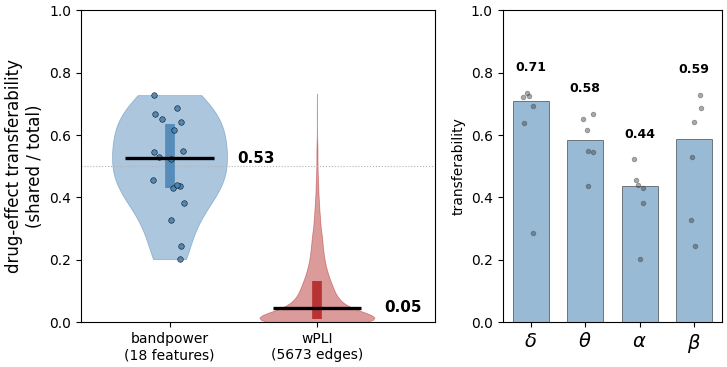

In [3]:
wpli_dt = edge.loc[edge["band"].isin(TAB_BANDS), "drug_transfer"].to_numpy()
bp_dt = bp.loc[bp["band"].isin(TAB_BANDS), "drug_transfer"].to_numpy()
bp_band_pts = {b: bp.loc[bp["band"] == b, "drug_transfer"].to_numpy() for b in PER_BAND}

# Greek band symbols (mathtext -> font-independent) for the per-band panel
GREEK = {"delta": r"$\delta$", "theta": r"$\theta$", "alpha": r"$\alpha$", "beta": r"$\beta$"}

def half(ax, pos, data, color, jitter=False):
    vp = ax.violinplot(data, positions=[pos], widths=0.78, showextrema=False, showmedians=False)
    for body in vp["bodies"]:
        body.set_facecolor(color); body.set_edgecolor(color); body.set_alpha(0.45)
    q25, med, q75 = np.percentile(data, [25, 50, 75])
    ax.vlines(pos, q25, q75, color=color, lw=7, alpha=0.85, zorder=4)
    ax.hlines(med, pos-0.3, pos+0.3, color="black", lw=2.4, zorder=6)
    if jitter:
        ax.scatter(pos + rng.uniform(-0.11, 0.11, len(data)), data, s=16, color=color,
                   edgecolors="black", linewidths=0.4, alpha=0.9, zorder=5)
    ax.annotate(f"{med:.2f}", xy=(pos, med), xytext=(pos+0.46, med), ha="left", va="center",
                fontsize=11, fontweight="bold")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(fig_width("double"), 3.9),
                               gridspec_kw={"width_ratios": [1.0, 0.62]})
# bandpower first (left), then wPLI (right)
half(axA, 0, bp_dt, C_BP, jitter=True); half(axA, 1, wpli_dt, C_WPLI)
axA.set_xticks([0, 1]); axA.set_xticklabels([f"bandpower\n({len(bp_dt)} features)", f"wPLI\n({len(wpli_dt)} edges)"])
axA.set_ylabel("drug-effect transferability\n(shared / total)"); axA.set_ylim(0, 1); axA.set_xlim(-0.6, 1.8)
axA.axhline(0.5, color="0.7", lw=0.8, ls=":")
xpos = np.arange(len(PER_BAND))
axB.bar(xpos, [np.median(bp_band_pts[b]) for b in PER_BAND], width=0.66, color=C_BP, alpha=0.55,
        edgecolor="black", linewidth=0.6)
for i, b in enumerate(PER_BAND):
    pts = bp_band_pts[b]
    axB.scatter(i + rng.uniform(-0.15, 0.15, len(pts)), pts, s=11, color="0.25", alpha=0.45)
    # median transferability above each bar (matches the median annotations in panel A)
    axB.text(i, min(pts.max() + 0.06, 0.95), f"{np.median(pts):.2f}", ha="center", va="bottom",
             fontsize=9, fontweight="bold")
axB.set_xticks(xpos); axB.set_xticklabels([GREEK[b] for b in PER_BAND], fontsize=14); axB.set_ylim(0, 1)
axB.set_ylabel("transferability", fontsize=10)
fig.tight_layout()
fig.savefig(c.FIGURE_DIR / "fingerprint_transferability.png", dpi=300, bbox_inches="tight")
fig.savefig(c.FIGURE_DIR / "fingerprint_transferability.pdf", bbox_inches="tight")
print("median drug_transfer  wPLI=%.3f  bandpower=%.3f" % (np.median(wpli_dt), np.median(bp_dt)))
plt.show()

## Figure: between-subject vs within-subject (drug) variance decomposition

saved fingerprint_variance_decomposition


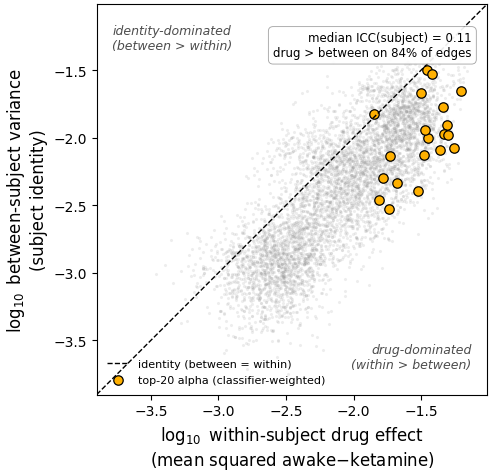

In [4]:
x = np.log10(edge["within_drug_msd"].to_numpy())
y = np.log10(edge["between_subj_var"].to_numpy())
xt = np.log10(top20["within_drug_msd"].to_numpy())
yt = np.log10(top20["between_subj_var"].to_numpy())
lo, hi = min(x.min(), y.min()) - 0.15, max(x.max(), y.max()) + 0.15
icc_med = float(edge["icc_subject"].median())
frac_drug = float((edge["ratio_between_over_within"] < 1).mean())

fig, ax = plt.subplots(figsize=(fig_width("single"), 5.0))
ax.scatter(x, y, s=5, c="0.55", alpha=0.15, linewidths=0, rasterized=True)
ax.plot([lo, hi], [lo, hi], color="black", lw=1.0, ls="--", label="identity (between = within)")
ax.scatter(xt, yt, s=46, facecolors=C_TOP, edgecolors="black", linewidths=0.9,
           label="top-20 alpha (classifier-weighted)")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$\log_{10}$ within-subject drug effect" "\n(mean squared awake$-$ketamine)")
ax.set_ylabel(r"$\log_{10}$ between-subject variance" "\n(subject identity)")
# Region annotations
ax.text(0.04, 0.95, "identity-dominated\n(between > within)", transform=ax.transAxes,
        ha="left", va="top", fontsize=9, style="italic", color="0.30")
ax.text(0.96, 0.06, "drug-dominated\n(within > between)", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=9, style="italic", color="0.30")
ax.text(0.96, 0.93, f"median ICC(subject) = {icc_med:.2f}\ndrug > between on {frac_drug:.0%} of edges",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="0.6", alpha=0.92))
ax.legend(loc="lower left", fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(c.FIGURE_DIR / "fingerprint_variance_decomposition.png", dpi=300, bbox_inches="tight")
fig.savefig(c.FIGURE_DIR / "fingerprint_variance_decomposition.pdf", bbox_inches="tight")
print("saved fingerprint_variance_decomposition")
plt.show()

## Figure: subject-ID confusion matrices (condition-aware CV)

saved fingerprint_subject_id_confusion


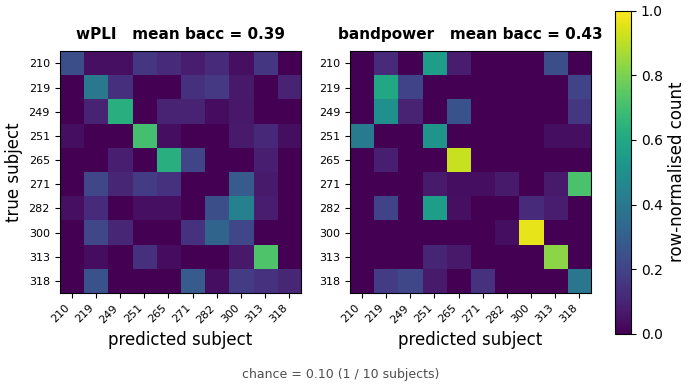

In [5]:
bacc_mean = acc.groupby("feature_set")["balanced_acc"].mean()
subjects = list(cm_wpli.index); n = len(subjects)
fig, axes = plt.subplots(1, 2, figsize=(fig_width("double"), 4.2))
im = None
for ax, (name, cm) in zip(axes, [("wPLI", cm_wpli), ("bandpower", cm_bp)]):
    norm = cm.to_numpy(float); norm = norm / norm.sum(axis=1, keepdims=True)
    im = ax.imshow(norm, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(subjects, rotation=45, ha="right", fontsize=8); ax.set_yticklabels(subjects, fontsize=8)
    ax.set_xlabel("predicted subject")
    ax.text(0.5, 1.04, f"{name}   mean bacc = {bacc_mean[name]:.2f}", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_ylabel("true subject")
cbar = fig.colorbar(im, ax=axes, fraction=0.045, pad=0.04); cbar.set_label("row-normalised count")
fig.text(0.5, 0.005, "chance = 0.10 (1 / 10 subjects)", ha="center", fontsize=9, color="0.30")
fig.savefig(c.FIGURE_DIR / "fingerprint_subject_id_confusion.png", dpi=300, bbox_inches="tight")
fig.savefig(c.FIGURE_DIR / "fingerprint_subject_id_confusion.pdf", bbox_inches="tight")
print("saved fingerprint_subject_id_confusion")
plt.show()

## Tables: transferability summary and subject-ID accuracy

In [6]:
display(pd.read_csv(T / "fingerprint_transferability_summary.csv").round(4))
display(acc.round(4))

,feature_set,median_drug_transfer,median_ratio_between_over_within,median_ratio_between_over_shared
0,wPLI,0.0462,0.5071,10.4093
1,bandpower,0.5475,0.8032,1.3431


,feature_set,train_cond,test_cond,n_train,n_test,balanced_acc
0,wPLI,awake,ketamine,141,135,0.3655
1,wPLI,ketamine,awake,135,141,0.4204
2,bandpower,awake,ketamine,141,135,0.4020
3,bandpower,ketamine,awake,135,141,0.4586
